In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import gym
import matplotlib.pyplot as plt
import random
import argparse
from collections import OrderedDict
from copy import copy
import scipy
import scipy.linalg
import sys
import os
sys.path.append("../utility")
sys.path.append("../train")
sys.path.append("../")
from Utility import data_collecter


from Utility import DerivativeLiftFunc, data_collecter,RBFLiftFunc

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
Methods = ["KoopmanDerivative","KoopmanRBF",\
            "KNonlinear","KNonlinearRNN","KoopmanU",\
            "KoopmanNonlinearA","KoopmanNonlinear",\
                ]

In [3]:
method_index = 1
# suffix = "CartPole1_26"
env_name = "CartPole-v1"
# suffix = "Pendulum1_26"
# env_name = "Pendulum-v1"
suffix = "DampingPendulum1_26"
# env_name = "DampingPendulum"
# env_name = "LunarLanderContinuous-v2"
# suffix = "MountainCarContinuous1_26"
# env_name = "MountainCarContinuous-v0"
# env_name = "DoublePendulum"

In [4]:
import numpy as np
from typing import Tuple, Optional
Data_collecter = data_collecter(env_name)
Nstate = Data_collecter.Nstates
udim = Data_collecter.udim
NKoopman = 50
import numpy as np
from typing import Tuple, Optional

class CFDLMFACController:
    def __init__(
        self,
        n: int,          # 状态维度
        m: int,          # 输入维度
        u_max: float,    # 输入幅值约束
        dt: float,       # 采样周期
        # 核心超参数
        eta: float = 0.8,     # PPD估计步长因子
        mu: float = 1e-4,     # PPD估计正则化项
        rho: float = 0.95,     # 控制律步长因子
        lambda_: float = 0.05, # 控制增量权重
        # 噪声适配优化超参数
        phi_init: float = 0.1, # PPD初始值
        phi_reset_thresh: float = 1e-3, # PPD重置阈值
        delta_u_reset_thresh: float = 1e-4, # 控制增量重置阈值
        forget_factor: float = 0.95, # 指数遗忘因子
        lp_filter_alpha: float = 0.1, # 低通滤波系数
    ):
        self.n = n
        self.m = m
        self.u_max = u_max
        self.dt = dt
        
        print(f"[Controller Init] State dim n={self.n}, Action dim m={self.m}")
        
        # 核心超参数
        self.eta = eta
        self.mu = mu
        self.rho = rho
        self.lambda_ = lambda_
        
        # 噪声适配优化超参数
        self.phi_init = phi_init
        self.phi_reset_thresh = phi_reset_thresh
        self.delta_u_reset_thresh = delta_u_reset_thresh
        self.forget_factor = forget_factor
        self.lp_filter_alpha = lp_filter_alpha
        
        # 历史数据存储
        self.x_obs_prev = None  # 上一步带噪声的观测状态
        self.u_prev = None       # 上一步控制输入
        self.phi_hat = None      # 当前伪偏导数估计 (n, m) 矩阵
        self.x_obs_filtered_prev = None # 上一步滤波后的观测状态
        
        self.reset()
    
    def reset(self):
        """重置控制器历史数据和PPD估计"""
        self.x_obs_prev = None
        # 🔥 强制确保 u_prev 是 (m,) 形状
        self.u_prev = np.zeros(self.m, dtype=np.float64)
        # 🔥 强制确保 phi_hat 是 (n, m) 形状
        self.phi_hat = self.phi_init * np.ones((self.n, self.m), dtype=np.float64)
        self.x_obs_filtered_prev = None
        print(f"[Controller Reset] Shapes: u_prev={self.u_prev.shape}, phi_hat={self.phi_hat.shape}")
    
    def _low_pass_filter(self, x_obs_new: np.ndarray, x_obs_filtered_prev: Optional[np.ndarray]) -> np.ndarray:
        """一阶低通滤波"""
        if x_obs_filtered_prev is None:
            return x_obs_new.copy()
        return self.lp_filter_alpha * x_obs_new + (1 - self.lp_filter_alpha) * x_obs_filtered_prev
    
    def _reset_phi_hat(self, delta_u: np.ndarray) -> bool:
        """PPD重置机制"""
        if np.linalg.norm(delta_u) < self.delta_u_reset_thresh:
            return True
        if np.linalg.norm(self.phi_hat) < self.phi_reset_thresh:
            return True
        return False
    
    def compute_control(self, x_obs: np.ndarray, x_des: np.ndarray) -> np.ndarray:
        """
        核心控制函数：带强制断言，维度100%安全
        """
        # ==========================================
        # 🔥 0. 入口维度强制检查
        # ==========================================
        x_obs = np.asarray(x_obs).flatten()
        x_des = np.asarray(x_des).flatten()
        assert x_obs.shape == (self.n,), f"Input x_obs shape error! Expected ({self.n},), got {x_obs.shape}"
        assert x_des.shape == (self.n,), f"Input x_des shape error! Expected ({self.n},), got {x_des.shape}"

        # 1. 观测状态低通滤波
        x_obs_filtered = self._low_pass_filter(x_obs, self.x_obs_filtered_prev)
        
        # 2. 初始化（仅第一次运行）
        if self.x_obs_prev is None:
            self.x_obs_prev = x_obs_filtered.copy()
            self.x_obs_filtered_prev = x_obs_filtered.copy()
            # 第一次控制：小步长趋近
            # 简单的比例控制
            u = self.rho * self.phi_init * (x_des - x_obs_filtered)
            # 🔥 确保 u 是 (m,)
            if self.n != self.m:
                # 如果状态和输入维度不同，第一次只取前 m 个维度的误差
                u = self.rho * self.phi_init * (x_des[:self.m] - x_obs_filtered[:self.m])
            
            u = np.clip(u, -self.u_max, self.u_max)
            # 强制类型转换
            self.u_prev = u.astype(np.float64).flatten()
            return self.u_prev
        
        # ==========================================
        # 3. 计算增量
        # ==========================================
        delta_x_obs = x_obs_filtered - self.x_obs_prev  # (n,)
        delta_u_prev = self.u_prev - np.zeros_like(self.u_prev)  # (m,)
        
        # ==========================================
        # 🔥 4. 维度断言：防止 delta_u_prev 变成 (n,)
        # ==========================================
        assert delta_x_obs.shape == (self.n,), f"delta_x shape error! Expected ({self.n},), got {delta_x_obs.shape}"
        assert delta_u_prev.shape == (self.m,), f"delta_u shape error! Expected ({self.m},), got {delta_u_prev.shape}"

        # ==========================================
        # 5. PPD在线递推估计（🔥 最稳妥写法）
        # ==========================================
        if not self._reset_phi_hat(delta_u_prev):
            # -----------------------------------------------------------
            # 🔥 核心修复：使用 np.outer + 断言
            # np.outer(a, b) 明确要求 a 是 (n,)，b 是 (m,)，输出 (n, m)
            # -----------------------------------------------------------
            outer_product = np.outer(delta_x_obs, delta_u_prev)
            
            # 🔥 再次断言外积结果
            assert outer_product.shape == (self.n, self.m), f"Outer product shape error! Expected ({self.n}, {self.m}), got {outer_product.shape}"
            assert self.phi_hat.shape == (self.n, self.m), f"phi_hat shape error! Expected ({self.n}, {self.m}), got {self.phi_hat.shape}"

            denominator = self.mu + np.linalg.norm(delta_u_prev)**2
            
            # PPD 更新（带遗忘因子）
            phi_hat_new = self.forget_factor * self.phi_hat + \
                          (self.eta / denominator) * outer_product
            
            self.phi_hat = phi_hat_new
        else:
            # 重置 PPD
            self.phi_hat = self.phi_init * np.ones((self.n, self.m), dtype=np.float64)
        
        # ==========================================
        # 6. 控制律解析求解
        # ==========================================
        error = x_des - x_obs_filtered  # (n,)
        
        if self.m == 1:
            # SISO 情况
            # 取 phi_hat 的第一列的均值或第一个元素作为代表
            phi_eff = np.mean(self.phi_hat[:, 0])
            # 为了稳定，通常只看第一个状态分量的误差
            delta_u = (self.rho * phi_eff * error[0]) / (self.lambda_ + phi_eff**2)
            delta_u = np.array([delta_u])
        else:
            # MIMO 情况：伪逆求解
            phi_T = self.phi_hat.T  # (m, n)
            phi_T_phi = phi_T @ self.phi_hat  # (m, m)
            regularization = self.lambda_ * np.eye(self.m)
            
            # 计算增益矩阵
            # 这里使用 pinv 防止奇异
            inv_part = np.linalg.pinv(phi_T_phi + regularization)
            gain = self.rho * inv_part @ phi_T
            delta_u = gain @ error  # (m,)
        
        # 7. 计算控制输入并约束
        u = self.u_prev + delta_u
        u = np.clip(u, -self.u_max, self.u_max)
        
        # 8. 更新历史数据
        self.x_obs_prev = x_obs_filtered.copy()
        self.x_obs_filtered_prev = x_obs_filtered.copy()
        self.u_prev = u.astype(np.float64).flatten()
        
        return self.u_prev

In [5]:

def Cost(observations,u_list,Q,R,x_ref):
    steps = observations.shape[1]
    loss = 0
    state_dim = x_ref.shape[0]
    for s in range(steps):
        if s!=steps-1:
            ucost = np.dot(np.dot(u_list[s].T,R),u_list[s])
            loss += ucost[0,0]
        xcost = np.dot(np.dot((observations[:,s]-x_ref).T,Q[:state_dim,:state_dim]),(observations[:,s]-x_ref))
        loss += xcost[0,0]
    return loss
def Prepare_LQR(env_name):
    x_ref = np.zeros(Nstate)
    if env_name.startswith("CartPole"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[1,1] = 0.01
        Q[2,2] = 5.0
        Q[3,3] = 0.01
        R = 0.001*np.eye(1)
        reset_state=  [0.0,-1.0,0.0,0]
    elif env_name.startswith("Pendulum"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[0,0] = 5.0
        Q[1,1] = 0.01
        R = 0.001*np.eye(1)
        reset_state = [-3.0,0.5]
    elif env_name.startswith("DampingPendulum"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[0,0] = 5.0
        Q[1,1] = 0.01
        R = 0.08*np.eye(1)
        reset_state = [-3,2]   
    elif env_name.startswith("DoublePendulum"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[0,0] = 5.0
        Q[1,1] = 5.0
        Q[2,2] = 0
        Q[3,3] = 0
        R = 0.001*np.eye(2)
        reset_state = [-1.5, 0.1, 0, 0]
    elif env_name.startswith("MountainCarContinuous"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[0,0] = 5.0
        Q[1,1] = 0.01
        R = 0.001*np.eye(1)
        reset_state = [0.5,0.0]  
        x_ref[0] = 0.45
    elif env_name.startswith("LunarLanderContinuous-v2"):
        Q = np.zeros((NKoopman,NKoopman))
        Q[0,0] = 20.0
        Q[1,1] = 20.0
        Q[2,2] = 5.0
        Q[3,3] = 5.0
        R = 0.001*np.eye(2)
        reset_state = [2.0,0.0]  
        x_ref[0] = 0
        x_ref[1] = 0
        x_ref[-1] = 0
        x_ref[-2] = 0
    Q = np.matrix(Q)
    R = np.matrix(R)
    return Q,R,reset_state,x_ref

[Controller Init] State dim n=4, Action dim m=1
[Controller Reset] Shapes: u_prev=(1,), phi_hat=(4, 1)


/home/xyrrrrrrrr/RDKRC2/control/../gym_env/cartpole.py:155: UserWarning: WARN: You are calling 'step()' even though this environment has already returned done = True. You should always call 'reset()' once you receive 'done = True' -- any further steps are undefined behavior.
  logger.warn(


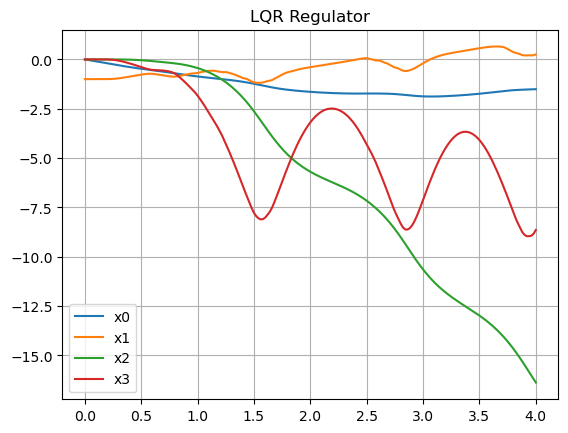

Total cost:  62308.829966427824


In [6]:
import lqr
import time
env = Data_collecter.env
env.reset()
Controller = CFDLMFACController(n=Nstate,m=udim,u_max=1.0,dt=env.dt)
Q,R,reset_state,x_ref = Prepare_LQR(env_name)
observation_list = []
if env_name == "LunarLanderContinuous-v2":
    observation = env.reset()
else:
    observation = env.reset_state(reset_state)
observation = np.array(observation)
x0 = observation
observation_list.append(observation.reshape(1,-1))
# print(Kopt)
u_list = []
steps = 200
for i in range(steps):
    u = Controller.compute_control(x0,x_ref)
    if udim == 1:
        ureal = u[0]
    else:
        ureal = [u[i] for i in range(udim)]
    observation, reward, done, info = env.step(np.array(ureal))
    x0 = observation
    observation_list.append(observation.reshape(1,-1))
    u_list.append(u)
    # time.sleep(0.1)
# print(observation_list)
observations = np.concatenate(observation_list,axis=0).T

np.save("./data/"+env_name+"_KoopmanRBF"+"_observations.npy",observations)
u_list = np.array(u_list).reshape(-1)
time_history = np.arange(steps+1)*env.dt
for i in range(Nstate):
    plt.plot(time_history, observations[i,:], label="x{}".format(i))
plt.grid(True)
plt.title("LQR Regulator")
plt.legend()
plt.show()
cost = Cost(observations,u_list,Q,R,x_ref)
print("Total cost: ",cost)

In [7]:
from typing import Tuple, List
def test_lander_lqr(
    net,  # 修正类型：适配DKN_MC2
    K_lqr,
    x_ref,
    num_episodes: int = 100,
    max_steps: int = 200,
    version: str = "MCDKN",
    seed: int = 2022
) -> List[float]:
    # 原函数逻辑不变，仅修正psi类型注解
    env = gym.make("LunarLanderContinuous-v2")
    env.seed(seed)
    # device = next(net.parameters()).device
    episode_scores: List[float] = []
    all_trajectories: List[List[Tuple[float, float]]] = []
    landing_positions: List[Tuple[float, float]] = []
    success_count = 0
    # net.eval()
    with torch.no_grad():
        for ep in range(num_episodes):
            observation = env.reset()
            done = False
            total_score = 0.0
            step = 0
            trajectory = []
            x0 = np.matrix(net.Psi_s(observation))
            x_ref_lift = net.Psi_s(x_ref)

            while not done and step < max_steps:
                x0 = x0.T
                trajectory.append((x0[0,0], x0[1,0]))
                # env.render()
                u = -Kopt*(x0-x_ref_lift)
                if udim == 1:
                    ureal = u[0,0]
                else:
                    ureal = [u[i,0] for i in range(udim)]
                # u = max(-umax,min(umax,u[0,0]))
                # print(type(u[0,0]),type(u))
                observation, reward, done, info = env.step(ureal)
                x0 = np.matrix(net.Psi_s(observation))
                # x0 = Ad*x0+Bd*u
                total_score += reward
                step += 1
            x0 = x0.T
            landing_x, landing_y = x0[0,0], x0[1,0]
            landing_positions.append((landing_x, landing_y))
            trajectory.append((landing_x, landing_y))
            all_trajectories.append(trajectory)
            episode_scores.append(total_score)
            if abs(landing_x) <= 0.5 and -0.2 <= landing_y <= 0.2:
                success_count += 1
            print(f"测试回合 {ep+1:2d}/{num_episodes} | 得分：{total_score:5.1f} | 步数：{step:3d} | 落地：(x={landing_x:.3f}, y={landing_y:.3f})")

    env.close()
    # 原落地统计与绘图逻辑不变...
    landing_xs = np.array([p[0] for p in landing_positions], dtype=np.float32)
    landing_ys = np.array([p[1] for p in landing_positions], dtype=np.float32)
    mean_x = np.mean(landing_xs)
    mean_y = np.mean(landing_ys)
    var_x = np.var(landing_xs, ddof=1)
    var_y = np.var(landing_ys, ddof=1)
    std_x = np.sqrt(var_x)
    std_y = np.sqrt(var_y)

    print(f"\n=== 落地位置统计 ===")
    x_ref_np = x_ref
    print(f"目标：(x={x_ref_np[0]:.3f}, y={x_ref_np[1]:.3f}) | 均值：(x={mean_x:.3f}, y={mean_y:.3f})")
    print(f"方差：var_x={var_x:.6f}, var_y={var_y:.6f} | 标准差：std_x={std_x:.3f}, std_y={std_y:.3f}")

    # 原轨迹绘图逻辑不变...
    plt.figure(figsize=(10, 8))
    colors = plt.cm.tab10.colors
    for ep, traj in enumerate(all_trajectories):
        x_coords = [p[0] for p in traj]
        y_coords = [p[1] for p in traj]
        plt.plot(x_coords, y_coords, color=colors[ep % len(colors)], alpha=0.7)

    plt.scatter(x_ref_np[0], x_ref_np[1], color="red", marker="s", s=80, label="Target")
    plt.scatter(mean_x, mean_y, color="blue", marker="o", s=100, label=f"Landing Mean")
    plt.gca().add_patch(plt.Rectangle((mean_x-std_x, mean_y-std_y), 2*std_x, 2*std_y, 
                                     color="blue", alpha=0.2, linestyle="--", label="±1σ"))
    plt.axhline(y=0, color="black", linestyle="--", alpha=0.8, label="Landing Pad")
    plt.xlim(-1.5, 1.5)
    plt.ylim(0, 1.5)
    plt.xlabel("X Position", fontsize=12)
    plt.ylabel("Y Position", fontsize=12)
    plt.title(f"Lunar Lander Trajectory ({version})", fontsize=14)
    plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1), fontsize=10)
    plt.show()
    os.makedirs("./fig/lunarlander", exist_ok=True)
    plt.savefig(f"./fig/lunarlander/trajectory_{version}.png", bbox_inches="tight", dpi=300)
    plt.close()

    avg_score = np.mean(episode_scores)
    std_score = np.std(episode_scores)
    print(f"\n=== 测试总结 ===")
    print(f"平均得分：{avg_score:.1f}±{std_score:.1f} | 成功着陆：{success_count}/{num_episodes}")
    return episode_scores

episode_scores = test_lander_lqr(LiftFunc, Kopt,x_ref)

NameError: name 'LiftFunc' is not defined